#### Autorzy

Jakub Kondys 151839 \
Kacper Dąbrowski 151521

In [1]:
# Najważniejsze importy
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Zbiór danych

Wykorzystaliśmy zbiór employee selection. Ma on 4 atrybuty warunkowe nieznanego znaczenia (udało się jedynie znaleźć znaczenie atrybutu decyzyjnego), przyjmujące wartości z zakresu [0,1] i 1 atrybut decyzyjny na który składa się 9 klas decyzyjnych. Klasy oznaczone przez liczby całkowite od 1 do 9, oznaczające jak bardzo pracownik nadaje się na stanowisko na króre się rektutuje.

Atrybut decyzyjny został zmapowany, tak jak w notebooku z zajęć RankSVM.ipynb binaryzując klasy. Klasy 1-5: 0, klasy 6-9: 1

In [2]:
def calculate_row_differences(input_array: np.ndarray) -> np.ndarray:
    """Calculate the difference between each row of a 2D array and all other rows.

    Args:
        input_array (np.ndarray): The input 2D array.

    Returns:
        np.ndarray: The resulting array with shape (n, m), where n is the number of rows in input_array
        and m is the number of columns in input_array. Each row of the resulting array is
        the difference between the corresponding row of input_array and all other rows.
    """
    num_rows, num_cols = input_array.shape
    row_strides = input_array.itemsize * num_cols
    
    a_strides = np.lib.stride_tricks.as_strided(
        input_array,
        (num_rows, num_rows, num_cols),
        (row_strides, 0, input_array.itemsize),
    )
    a_reshaped = a_strides.reshape(-1, num_cols)
    
    b_strides = np.lib.stride_tricks.as_strided(
        input_array,
        (num_rows, num_rows, num_cols),
        (0, row_strides, input_array.itemsize),
    )
    b_reshaped = b_strides.reshape(-1, num_cols)
    
    return a_reshaped - b_reshaped

def load_data(path: str, target_map: dict, criteria_nr: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Preprocesses the data for training a machine learning model.

    Args:
        path (str): The path to the CSV file containing the data.
        target_map (dict): A dictionary mapping target values to binary labels.
        criteria_nr (int): The number of criteria used for classification.

    Returns:
        tuple: A tuple containing the preprocessed data and the train-test split.
    """
    # Read the data from the CSV file
    data = pd.read_csv(path, header=None)

    # Apply the target mapping to convert target values to binary labels
    data[criteria_nr] = data[criteria_nr].apply(lambda x: target_map[x])

    # Remove duplicate rows from the data
    data = data.drop_duplicates()

    # Split the data into input features and target variable
    data_input = data.iloc[:, :criteria_nr].values
    data_target = data[criteria_nr].values

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        data_input, data_target, test_size=0.2, random_state=1234
    )

    return (X_train, X_test, y_train, y_test)


In [3]:
# Load the data and preprocess it
path = "monodata/employee selection.csv"
target_map = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 1, 7: 1, 8: 1, 9: 1}
criteria_nr = 4
X_train_data, X_test_data, y_train_data, y_test_data = load_data(path, target_map, criteria_nr)

# RankSVM

Kod obu etapów (obliczenie różnic w ocenach wariantu z wariantami innej klasy by stworzyć nowy zbiór, wykonanie SVM na nowym zbiorze) wzięte z notebooka RankSVM.ipynb z zajęć.

In [4]:
X_train, X_test, y_train, y_test = X_train_data, X_test_data, y_train_data, y_test_data

# Calculate the differences between each row of the input features
X_train = calculate_row_differences(X_train)
X_test = calculate_row_differences(X_test)
y_train = calculate_row_differences(y_train.reshape(-1, 1))[:, 0]
y_test = calculate_row_differences(y_test.reshape(-1, 1))[:, 0]

# Take only the rows where the target variable is not 0, so they are in the diffrent class
scaller = StandardScaler()
X_train = X_train[y_train != 0]
X_train = scaller.fit_transform(X_train)
y_train = y_train[y_train != 0]

X_test = X_test[y_test != 0]
X_test = scaller.transform(X_test)
y_test = y_test[y_test != 0]


In [5]:
# Create a linear SVM model
model = svm.LinearSVC()

# Fit the model to the training data
_ = model.fit(X_train,y_train)

In [6]:
y_pred_train = model.predict(X_train)
out_train = np.dot(X_train, model.coef_.T)
accuracy_train = accuracy_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, out_train)
f1_train = f1_score(y_train, y_pred_train)
print(f"Accuracy train:\t{accuracy_train:.2%}")
print(f"AUC train: \t{auc_train:.2%}")
print(f"F1 train: \t{f1_train:.2%}\n")

y_pred_test = model.predict(X_test)
out_test = np.dot(X_test, model.coef_.T)
accuracy_test = accuracy_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, out_test) 
f1_test = f1_score(y_test, y_pred_test)
print(f"Accuracy test:\t{accuracy_test:.2%}")
print(f"AUC test: \t{auc_test:.2%}")
print(f"F1 test: \t{f1_test:.2%}")


Accuracy train:	97.31%
AUC train: 	99.72%
F1 train: 	97.31%

Accuracy test:	96.10%
AUC test: 	99.64%
F1 test: 	96.10%


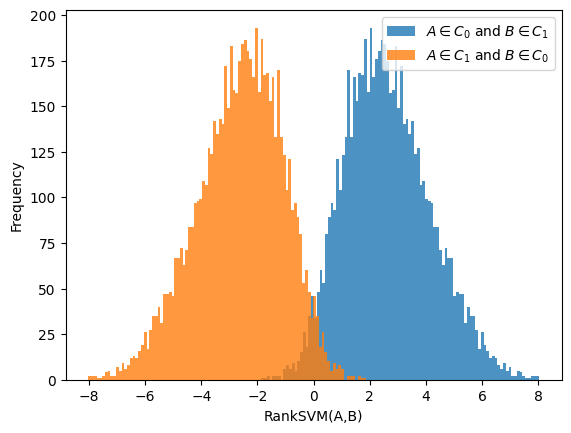

In [7]:
# Class distribution of training data
plt.hist(out_train[y_train==1], alpha=0.8, bins=100, label='$A \in C_0$ and $B \in C_1$') # A in C0 and B in C1 so score should be positive
plt.hist(out_train[y_train==-1], alpha=0.8, bins=100, label='$A \in C_1$ and $B \in C_0$') # A in C1 and B in C0 so score should be negative
plt.xlabel("RankSVM(A,B)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

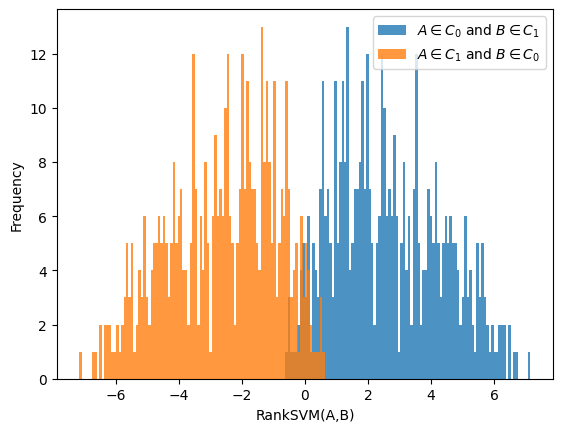

In [8]:
# Class distribution of test data
plt.hist(out_test[y_test==1], alpha=0.8, bins=100, label='$A \in C_0$ and $B \in C_1$') # A in C0 and B in C1 so score should be positive
plt.hist(out_test[y_test==-1], alpha=0.8, bins=100, label='$A \in C_1$ and $B \in C_0$') # A in C1 and B in C0 so score should be negative
plt.xlabel("RankSVM(A,B)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [9]:
# Model coefficients
w = model.coef_[0]
print(f'Criteria coefficients {w}')
b = model.intercept_[0]
print(f'Intercept {b}')

Criteria coefficients [1.04364937 0.22586755 0.91984092 1.28262942]
Intercept -3.2432033749283827e-13


In [10]:
def plot_density(X_train: np.ndarray, y_train: np.ndarray, criterion_1: int, criterion_2: int, samples: int = 10000) -> None:
    """Plot the density of the training data and the decision boundary. Plots only pairs of criteria criterion_1 and criterion_2. 

    Args:
        X_train (np.ndarray): Input features of the training data.
        y_train (np.ndarray): Target variable of the training data.
        criterion_1 (int): The index of the first criterion.
        criterion_2 (int): The index of the second criterion.
        samples (int, optional): The number of samples to plot. Defaults to 10000.

    """
    # Plot the density of the training data
    axes = sns.jointplot(
        x=X_train[:samples, criterion_1],
        y=X_train[:samples, criterion_2],
        hue=y_train[:samples],
        kind="kde",
        palette=["green", "red"],
        fill=True,
        alpha=0.5,
    )
    
    # Plot the decision boundary
    x_points = np.linspace(-2*w[criterion_2], 2*w[criterion_2])
    y_points = -(w[criterion_1] / w[criterion_2]) * x_points - b / w[criterion_2]
    x_points = x_points[np.logical_and(y_points < 1, y_points > -1)]
    y_points = y_points[np.logical_and(y_points < 1, y_points > -1)]
    axes.ax_joint.plot(x_points, y_points, c="blue")
    
    # Set labels for axes
    axes.ax_joint.set_xlabel(f"Criterion: {criterion_1}")
    axes.ax_joint.set_ylabel(f"Criterion: {criterion_2}")


In [11]:
def plot_density_variant(X_train: np.ndarray, y_train: np.ndarray, criterion_1: int, criterion_2: int, samples: int = 10000):
    axes = sns.jointplot(
        x=X_train[:samples, criterion_1],
        y=X_train[:samples, criterion_2],
        hue=y_train[:samples],
        kind="kde",
        palette=["green", "red"],
        fill=True,
        alpha=0.5,
    )
    
    x_points = np.linspace(-2*w[criterion_2], 2*w[criterion_2], 200)
    y_points = -(w[criterion_1] / w[criterion_2]) * x_points - b / w[criterion_2]
    mask = (y_points > axes.ax_joint.get_ylim()[0]) & (y_points < axes.ax_joint.get_ylim()[1])
    axes.ax_joint.plot(x_points[mask], y_points[mask], c="blue")
    
    axes.ax_joint.set_xlabel(f"Criterion: {criterion_1}")
    axes.ax_joint.set_ylabel(f"Criterion: {criterion_2}")
    
    return axes.figure  # zwracamy figurę jointplot

#### Wagi modelu

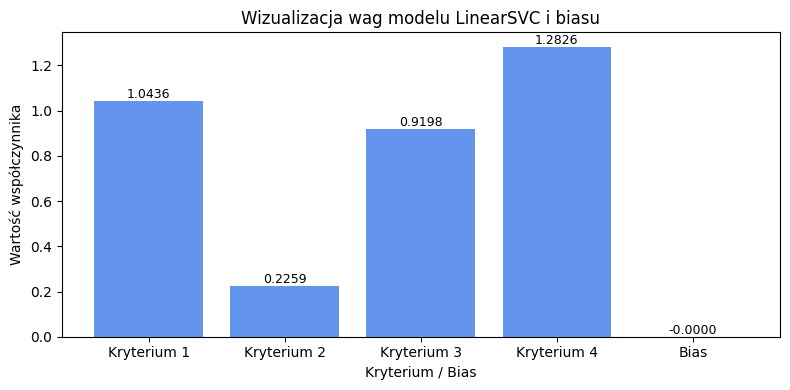

In [12]:
# Zaokrąglenie wag i biasu
weights = np.round(model.coef_[0], 4)
bias = np.round(model.intercept_[0], 4)

plt.figure(figsize=(8, 4))

# Słupki dla wag
bars = plt.bar(range(len(weights)), weights, color='cornflowerblue')

# Dodajemy słupek biasu (jako czwarty słupek)
bars_bias = plt.bar(len(weights), bias, color='salmon')

# Etykiety osi X (wagi + bias)
plt.xticks(list(range(len(weights))) + [len(weights)], [f'Kryterium {i+1}' for i in range(len(weights))] + ['Bias'])
plt.xlabel('Kryterium / Bias')
plt.ylabel('Wartość współczynnika')
plt.title('Wizualizacja wag modelu LinearSVC i biasu')

# Dodanie wartości nad słupkami wag
for bar, val in zip(bars, weights):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Dodanie wartości nad słupkiem biasu
height = bars_bias.patches[0].get_height()
plt.text(bars_bias.patches[0].get_x() + bars_bias.patches[0].get_width() / 2, height,
         f'{bias:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Wagi oznaczają ważność kryterium. Zatem kryterium 4 jest najważnejsze, ma najsilniejszy wpływ na separację klas. Mniej ważne są kryteria 1 i 3, a z kolei kryterium 2 ma najmniejszy wpływ na separację klas.

Bias w przybliżeniu 0 - granica decyzyjna przechodzi przez środek układu współrzędnych.

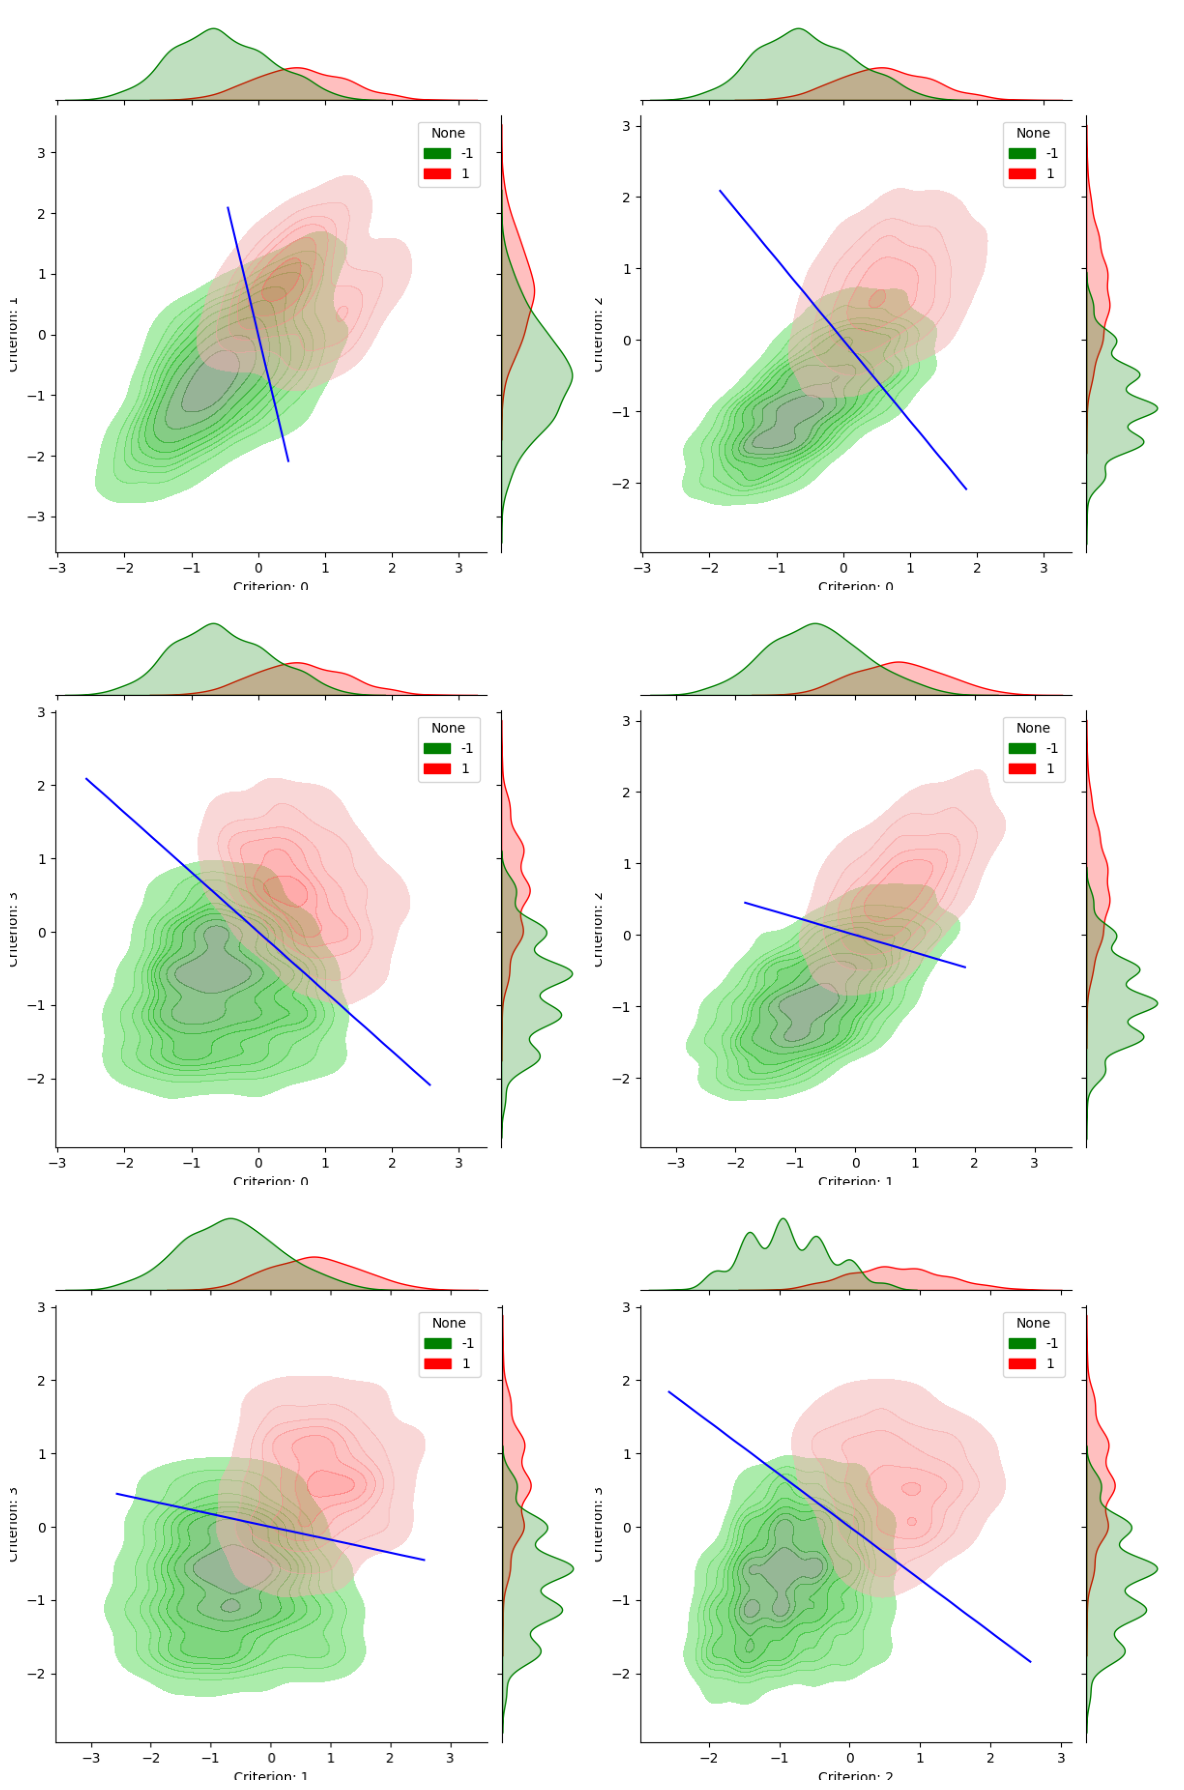

In [13]:
from itertools import combinations

w = model.coef_[0]
b = model.intercept_[0]

criterion_indices = range(X_train.shape[1])
pairs = list(combinations(criterion_indices, 2))

n_cols = 2
n_rows = (len(pairs) + 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 6 * n_rows))
axs = axs.flatten()

for i, (c1, c2) in enumerate(pairs):
    fig_joint = plot_density_variant(X_train, y_train, c1, c2, samples=1000)
    fig_joint.canvas.draw()
    
    # Pobierz obraz z jointplot jako numpy array (RGBA)
    img = np.frombuffer(fig_joint.canvas.buffer_rgba(), dtype='uint8')
    img = img.reshape(fig_joint.canvas.get_width_height()[::-1] + (4,))

    
    plt.close(fig_joint)
    
    axs[i].imshow(img)
    axs[i].axis('off')

# Ukryj nieużywane osie, jeśli są
for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


#### Wyjaśnienie decyzji

In [14]:
example_indices = [10, 25, 2]

w = model.coef_[0]
b = model.intercept_[0]

for idx in example_indices:
    x = X_test[idx]
    true_label = y_test[idx]
    
    decision_value = np.dot(w, x) + b
    predicted_class = 1 if decision_value >= 0 else -1
    
    print(f"\nPrzykład {idx}:")
    print(f"  Prawdziwa klasa: {true_label}")
    print(f"  Przewidywana klasa: {predicted_class}")
    print(f"  Wartość funkcji decyzyjnej (w·x + b): {decision_value:.4f}")
    
    feature_contributions = w * x
    sorted_idx = np.argsort(np.abs(feature_contributions))[::-1]
    
    print("  Wpływ cech na decyzję (współczynnik * wartość cechy):")
    for i in sorted_idx:
        support_class = 1 if feature_contributions[i] > 0 else 0
        print(f"Kryterium {i+1}: {feature_contributions[i]:+.4f} (w: {w[i]:.4f}, x: {x[i]:.4f}) → wspiera klasę {support_class}")



Przykład 10:
  Prawdziwa klasa: 1
  Przewidywana klasa: 1
  Wartość funkcji decyzyjnej (w·x + b): 5.2001
  Wpływ cech na decyzję (współczynnik * wartość cechy):
Kryterium 1: +2.4106 (w: 1.0436, x: 2.3098) → wspiera klasę 1
Kryterium 3: +1.7509 (w: 0.9198, x: 1.9035) → wspiera klasę 1
Kryterium 4: +0.7257 (w: 1.2826, x: 0.5658) → wspiera klasę 1
Kryterium 2: +0.3129 (w: 0.2259, x: 1.3852) → wspiera klasę 1

Przykład 25:
  Prawdziwa klasa: -1
  Przewidywana klasa: -1
  Wartość funkcji decyzyjnej (w·x + b): -1.5078
  Wpływ cech na decyzję (współczynnik * wartość cechy):
Kryterium 4: -0.7257 (w: 1.2826, x: -0.5658) → wspiera klasę 0
Kryterium 3: -0.4377 (w: 0.9198, x: -0.4759) → wspiera klasę 0
Kryterium 1: -0.3444 (w: 1.0436, x: -0.3300) → wspiera klasę 0
Kryterium 2: +0.0000 (w: 0.2259, x: 0.0000) → wspiera klasę 1

Przykład 2:
  Prawdziwa klasa: 1
  Przewidywana klasa: 1
  Wartość funkcji decyzyjnej (w·x + b): 1.9565
  Wpływ cech na decyzję (współczynnik * wartość cechy):
Kryterium 1: 

In [15]:
pairs_to_explain = [(10, 3), (3, 2), (10, 2)]

w = model.coef_[0]
b = model.intercept_[0]

for idx1, idx2 in pairs_to_explain:
    x1_orig = X_test_data[idx1]
    x2_orig = X_test_data[idx2]
    
    y1 = y_test_data[idx1]
    y2 = y_test_data[idx2]
    
    # Liczymy różnicę w oryginalnej skali
    x_diff_orig = x1_orig - x2_orig
    
    # Skalujemy różnicę jako jedną próbkę
    x_diff_scaled = scaller.transform(x_diff_orig.reshape(1, -1))[0]
    
    # Obliczamy ocenę różnicy — to właśnie model ocenia
    diff = np.dot(w, x_diff_scaled)
    
    predicted = 1 if diff >= 0 else -1  # klasyfikacja pary
    
    print(f"\nPara wariantów {idx1} (klasa {y1}) i {idx2} (klasa {y2}):")
    print(f"  Przeskalowana różnica (ocena modelu): {diff:.4f}")
    print(f"  Przewidywana preferencja: wariant {idx1 if predicted==1 else idx2}")
    
    feature_contribs = w * x_diff_scaled
    sorted_idx = np.argsort(np.abs(feature_contribs))[::-1]
    
    print("  Wpływ cech na różnicę decyzji (współczynnik * przeskalowana różnica):")
    for i in sorted_idx:
        support_variant = idx1 if feature_contribs[i] > 0 else idx2
        print(f"    Kryterium {i+1}: {feature_contribs[i]:+.4f} → wspiera wariant {support_variant}")



Para wariantów 10 (klasa 0) i 3 (klasa 1):
  Przeskalowana różnica (ocena modelu): -2.3117
  Przewidywana preferencja: wariant 3
  Wpływ cech na różnicę decyzji (współczynnik * przeskalowana różnica):
    Kryterium 4: -1.4514 → wspiera wariant 3
    Kryterium 3: -0.4377 → wspiera wariant 3
    Kryterium 1: -0.3444 → wspiera wariant 3
    Kryterium 2: -0.0782 → wspiera wariant 3

Para wariantów 3 (klasa 1) i 2 (klasa 0):
  Przeskalowana różnica (ocena modelu): 3.0787
  Przewidywana preferencja: wariant 3
  Wpływ cech na różnicę decyzji (współczynnik * przeskalowana różnica):
    Kryterium 4: +1.4514 → wspiera wariant 3
    Kryterium 1: +1.0331 → wspiera wariant 3
    Kryterium 3: +0.4377 → wspiera wariant 3
    Kryterium 2: +0.1564 → wspiera wariant 3

Para wariantów 10 (klasa 0) i 2 (klasa 0):
  Przeskalowana różnica (ocena modelu): 0.7670
  Przewidywana preferencja: wariant 10
  Wpływ cech na różnicę decyzji (współczynnik * przeskalowana różnica):
    Kryterium 1: +0.6887 → wspiera w

Widać, że wariant 3 jest wg. modelu wyżej w rankingu, co zgadza się z jego wyższą klasą(1) od pozostałych(0).

#### Zmiana predykcji po zmianie 1 kryterium

##### Analitycznie

Analitycznie wymagana zmiana na kryterium to różnica predykcji podzielona przez wagę kryterium.

In [16]:
pairs_to_explain = [(10, 3), (3, 2), (10, 2)]
w = model.coef_[0]
b = model.intercept_[0]

for idx1, idx2 in pairs_to_explain:
    x1_orig = X_test_data[idx1].copy()
    x2_orig = X_test_data[idx2].copy()

    x_diff_orig = x1_orig - x2_orig
    x_diff_scaled = scaller.transform(x_diff_orig.reshape(1, -1))[0]
    diff = np.dot(w, x_diff_scaled) + b

    print(f"\nPara wariantów {idx1} (klasa {y_test_data[idx1]}) i {idx2} (klasa {y_test_data[idx2]}):")
    print(f"  Obecna różnica score: {diff:.4f}")

    min_change = float('inf')
    best_variant = None
    best_feature = None
    best_delta_scaled = None
    best_new_val_scaled = None
    best_delta_orig = None
    best_new_val_orig = None

    for i in range(len(w)):
        if w[i] == 0:
            continue

        # Próba zmiany x1
        delta_scaled_1 = -diff / w[i]
        x1_scaled = scaller.transform(x1_orig.reshape(1, -1))[0]
        x1_scaled_mod = x1_scaled.copy()
        x1_scaled_mod[i] += delta_scaled_1
        x1_mod = scaller.inverse_transform(x1_scaled_mod.reshape(1, -1))[0]
        delta_orig_1 = x1_mod[i] - x1_orig[i]

        if abs(delta_orig_1) < min_change:
            min_change = abs(delta_orig_1)
            best_variant = idx1
            best_feature = i
            best_delta_scaled = delta_scaled_1
            best_new_val_scaled = x1_scaled_mod[i]
            best_delta_orig = delta_orig_1
            best_new_val_orig = x1_mod[i]

        # Próba zmiany x2
        delta_scaled_2 = diff / w[i]
        x2_scaled = scaller.transform(x2_orig.reshape(1, -1))[0]
        x2_scaled_mod = x2_scaled.copy()
        x2_scaled_mod[i] += delta_scaled_2
        x2_mod = scaller.inverse_transform(x2_scaled_mod.reshape(1, -1))[0]
        delta_orig_2 = x2_mod[i] - x2_orig[i]

        if abs(delta_orig_2) < min_change:
            min_change = abs(delta_orig_2)
            best_variant = idx2
            best_feature = i
            best_delta_scaled = delta_scaled_2
            best_new_val_scaled = x2_scaled_mod[i]
            best_delta_orig = delta_orig_2
            best_new_val_orig = x2_mod[i]

    print(f"  Minimalna zmiana dla zmiany decyzji:")
    print(f"    Wariant {best_variant}, Kryterium {best_feature+1}")
    print(f"    Zmiana wartości (przeskalowana): {best_delta_scaled:+.4f}")
    print(f"    Nowa wartość cechy (przeskalowana): {best_new_val_scaled:.4f}")
    print(f"    Zmiana wartości (oryginalna skala): {best_delta_orig:+.4f}")
    print(f"    Nowa wartość cechy (oryginalna skala): {best_new_val_orig:.4f}")



Para wariantów 10 (klasa 0) i 3 (klasa 1):
  Obecna różnica score: -2.3117
  Minimalna zmiana dla zmiany decyzji:
    Wariant 10, Kryterium 4
    Zmiana wartości (przeskalowana): +1.8023
    Nowa wartość cechy (przeskalowana): 3.4997
    Zmiana wartości (oryginalna skala): +0.5309
    Nowa wartość cechy (oryginalna skala): 1.0309

Para wariantów 3 (klasa 1) i 2 (klasa 0):
  Obecna różnica score: 3.0787
  Minimalna zmiana dla zmiany decyzji:
    Wariant 3, Kryterium 4
    Zmiana wartości (przeskalowana): -2.4003
    Nowa wartość cechy (przeskalowana): 0.4287
    Zmiana wartości (oryginalna skala): -0.7071
    Nowa wartość cechy (oryginalna skala): 0.1263

Para wariantów 10 (klasa 0) i 2 (klasa 0):
  Obecna różnica score: 0.7670
  Minimalna zmiana dla zmiany decyzji:
    Wariant 10, Kryterium 4
    Zmiana wartości (przeskalowana): -0.5980
    Nowa wartość cechy (przeskalowana): 1.0994
    Zmiana wartości (oryginalna skala): -0.1761
    Nowa wartość cechy (oryginalna skala): 0.3239


Oczywiście znalezione kryterium to 4, bo ma największą wagę, jego zmiana najbardziej wpłynie na wynik. Niestety wartości kryteriów dla pary 10, 3 wychodzą poza zakres [0,1]

##### Próbkowanie przestrzeni

In [17]:
pairs_to_explain = [(10, 3), (3, 2), (10, 2)]
w = model.coef_[0]
b = model.intercept_[0]

for idx1, idx2 in pairs_to_explain:
    x1_orig = X_test_data[idx1].copy()
    x2_orig = X_test_data[idx2].copy()

    x1_scaled = scaller.transform(x1_orig.reshape(1, -1))[0]
    x2_scaled = scaller.transform(x2_orig.reshape(1, -1))[0]

    diff = np.dot(w, x1_scaled - x2_scaled) + b

    print(f"\nPara wariantów {idx1} (klasa {y_test_data[idx1]}) i {idx2} (klasa {y_test_data[idx2]}):")
    print(f"  Obecna różnica score: {diff:.4f}")

    min_change = float('inf')
    best_variant = None
    best_feature = None
    best_delta_scaled = None
    best_new_val_scaled = None
    best_delta_orig = None
    best_new_val_orig = None

    for i in range(len(w)):
        if w[i] == 0:
            continue

        # Próba zmiany x1
        delta_scaled_1 = -diff / w[i]
        x1_scaled_mod = x1_scaled.copy()
        x1_scaled_mod[i] += delta_scaled_1
        x1_mod = scaller.inverse_transform(x1_scaled_mod.reshape(1, -1))[0]
        delta_orig_1 = x1_mod[i] - x1_orig[i]

        if abs(delta_orig_1) < min_change:
            min_change = abs(delta_orig_1)
            best_variant = idx1
            best_feature = i
            best_delta_scaled = delta_scaled_1
            best_new_val_scaled = x1_scaled_mod[i]
            best_delta_orig = delta_orig_1
            best_new_val_orig = x1_mod[i]

        # Próba zmiany x2
        delta_scaled_2 = diff / w[i]
        x2_scaled_mod = x2_scaled.copy()
        x2_scaled_mod[i] += delta_scaled_2
        x2_mod = scaller.inverse_transform(x2_scaled_mod.reshape(1, -1))[0]
        delta_orig_2 = x2_mod[i] - x2_orig[i]

        if abs(delta_orig_2) < min_change:
            min_change = abs(delta_orig_2)
            best_variant = idx2
            best_feature = i
            best_delta_scaled = delta_scaled_2
            best_new_val_scaled = x2_scaled_mod[i]
            best_delta_orig = delta_orig_2
            best_new_val_orig = x2_mod[i]

    print(f"  Minimalna zmiana dla zmiany decyzji:")
    print(f"    Wariant {best_variant}, Kryterium {best_feature+1}")
    print(f"    Zmiana wartości (przeskalowana): {best_delta_scaled:+.4f}")
    print(f"    Nowa wartość cechy (przeskalowana): {best_new_val_scaled:.4f}")
    print(f"    Zmiana wartości (oryginalna skala): {best_delta_orig:+.4f}")
    print(f"    Nowa wartość cechy (oryginalna skala): {best_new_val_orig:.4f}")



Para wariantów 10 (klasa 0) i 3 (klasa 1):
  Obecna różnica score: -2.3117
  Minimalna zmiana dla zmiany decyzji:
    Wariant 10, Kryterium 4
    Zmiana wartości (przeskalowana): +1.8023
    Nowa wartość cechy (przeskalowana): 3.4997
    Zmiana wartości (oryginalna skala): +0.5309
    Nowa wartość cechy (oryginalna skala): 1.0309

Para wariantów 3 (klasa 1) i 2 (klasa 0):
  Obecna różnica score: 3.0787
  Minimalna zmiana dla zmiany decyzji:
    Wariant 3, Kryterium 4
    Zmiana wartości (przeskalowana): -2.4003
    Nowa wartość cechy (przeskalowana): 0.4287
    Zmiana wartości (oryginalna skala): -0.7071
    Nowa wartość cechy (oryginalna skala): 0.1263

Para wariantów 10 (klasa 0) i 2 (klasa 0):
  Obecna różnica score: 0.7670
  Minimalna zmiana dla zmiany decyzji:
    Wariant 10, Kryterium 4
    Zmiana wartości (przeskalowana): -0.5980
    Nowa wartość cechy (przeskalowana): 1.0994
    Zmiana wartości (oryginalna skala): -0.1761
    Nowa wartość cechy (oryginalna skala): 0.3239


Próbkowanie potwierdza wyniki analityczne

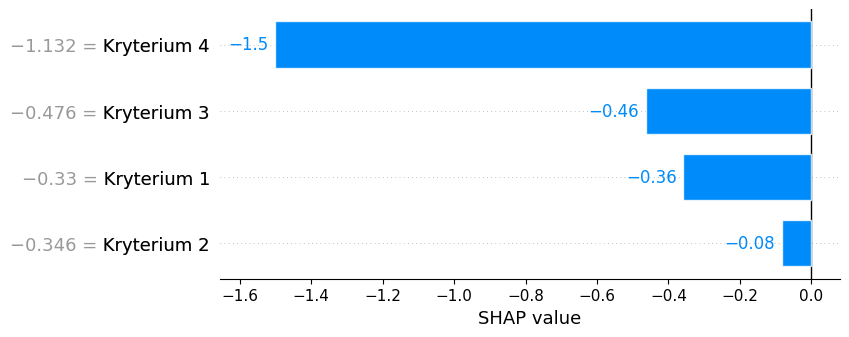

In [18]:
import shap

explainer = shap.LinearExplainer(model, X_train)

feature_names = [f"Kryterium {i+1}" for i in range(X_train_data.shape[1])]

pair_to_explain = (10, 3) # Niestety w 1 komórce się nie wyświetla kilka razy force_plot

x1_orig = X_test_data[pair_to_explain[0]]
x2_orig = X_test_data[pair_to_explain[1]]

# Różnica cech w oryginalnej skali
x_diff_orig = x1_orig - x2_orig

# Skalujemy różnicę jako jedną próbkę
x_diff_scaled = scaller.transform(x_diff_orig.reshape(1, -1))[0]

# SHAP wyjaśnia tę skalowaną różnicę
shap_values = explainer.shap_values(x_diff_scaled.reshape(1, -1))[0]

# print(f"\nPara wariantów {idx1} (klasa {y_test_data[idx1]}) i {idx2} (klasa {y_test_data[idx2]}):")
# for i, val in enumerate(shap_values):
#     print(f"  {feature_names[i]}: {val:.4f}")

# Wizualizacja różnicy
shap.initjs()
shap.plots.bar(shap.Explanation(values=shap_values, 
                                base_values=explainer.expected_value,
                                data=x_diff_scaled,
                                feature_names=feature_names))
shap.force_plot(explainer.expected_value, shap_values, x_diff_scaled, feature_names=feature_names)


Dla pary wariantów 10 i 3 kryteria wpływały na wynik najsilniej w tej kolejności: 4, 3, 1, 2.
Dla pary 10 i 2 było to 1, 2, 3, 4.
Z kolei dla pary 3, 2 były to 4, 1, 3, 2

Zgadza się to z wcześniejszą analizą w sekcji analitycznej.

Taki wynik jest konsekwencją wysokiej wartości na 4 kryterium przykładu 3 i braku różnic między 10 i 2 na kryterium 3 i 4

In [19]:
example_indices = [10, 3, 2]

for _, idx in enumerate(example_indices):
    print(f"example {idx}:\n{X_test_data[idx]} class:{y_train_data[idx]}\n")

example 10:
[0.777778 0.666667 0.5      0.5     ] class:0

example 3:
[0.888889 0.777778 0.666667 0.833333] class:1

example 2:
[0.555556 0.555556 0.5      0.5     ] class:0



#### Interpretacja modelu

Tak jak pokazano wcześniej kryterium 4 jest najważniejsze, 2 ma najmniejszy wpływ. Jest to wprost związane zwagami, gdyż kryteria zostały znormalizowane.

In [20]:
for i in range(len(weights)):
    print(f"Kryterium {i+1} waga/wpływ: {weights[i]:.4f}")

Kryterium 1 waga/wpływ: 1.0436
Kryterium 2 waga/wpływ: 0.2259
Kryterium 3 waga/wpływ: 0.9198
Kryterium 4 waga/wpływ: 1.2826


Wszystkie wagi są dodatnie zatem wszystkie kryteria są typu koszt.

Progi preferencji w naszym przykładzie RankSVM nie istnieją - nawet minimalna zmiana wartości kryterium może zmienić decyzję.

In [21]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(model, scoring='accuracy', random_state=42).fit(X_test, y_test)

# Ważność cech
eli5.show_weights(perm, feature_names=feature_names)


Weight,Feature
0.1229 ± 0.0175,Kryterium 1
0.1030 ± 0.0200,Kryterium 4
0.0790 ± 0.0071,Kryterium 3
0.0229 ± 0.0054,Kryterium 2


Zgodnie z wynikiem Permiutation Feature Importance najważniejsze kryterium to 1, następnie kolejno 4, 3, 2.
2 zdecydowanie najgorsze co się pokrywa z wagami modelu, jednak pozostałe kryteria są wymieszane w porównaniu z wagami.

Te wyniki nie pokrywają się z naszą poprzednią analizą - kryterium 1 zamienione kolejnością z 4. Chociaż można zauważyć, że wartości wag są bardzo zbliżone do wag modelu. Jest to ciekawe, gdyż wydawało się, że model jest bardzo dobry - wyniki F1, AUC i Accuracy na zbiorze testowym.

Testowanie na danych testowych zatem dużo zmienia.

## ANN-UTADIS

Mała uwaga - w plikach lab z lab10 (Uczenie preferencji) jeden z plików miał inną nazwę niż pozostałe go importowały - criterion_layer_spread, a importowane było criterion_layer_spread_uniform_center (albo ewentualnie tego pliku brakowało). W każdym razie my zmieniliśmy nazwę pliku criterion_layer_spread.py -> criterion_layer_spread_uniform_center.py; więc jeśli jakieś wyniki się nie zgadzają czy działanie samego modelu to możliwe, że przez to.

In [22]:
import torch
from utils import *
from uta import Uta
from norm_layer import NormLayer

PATH = "uta.pt2"

##### Data load

In [23]:
X_train, X_test, y_train, y_test = X_train_data, X_test_data, y_train_data, y_test_data

train_dataloader = CreateDataLoader(X_train, y_train)
test_dataloader = CreateDataLoader(X_test, y_test)

num_criteria = criteria_nr

#### Model creation and training

In [24]:
# Create model and train
uta = Uta(num_criteria, 30)
model = NormLayer(uta, num_criteria)
(
    best_acc,
    best_auc,
    stats_train,
    stats_test,
) = Train(model, train_dataloader, test_dataloader, PATH, epoch_nr=200,lr =0.0001,slope_decrease=True)

100%|██████████| 200/200 [00:01<00:00, 142.35it/s]


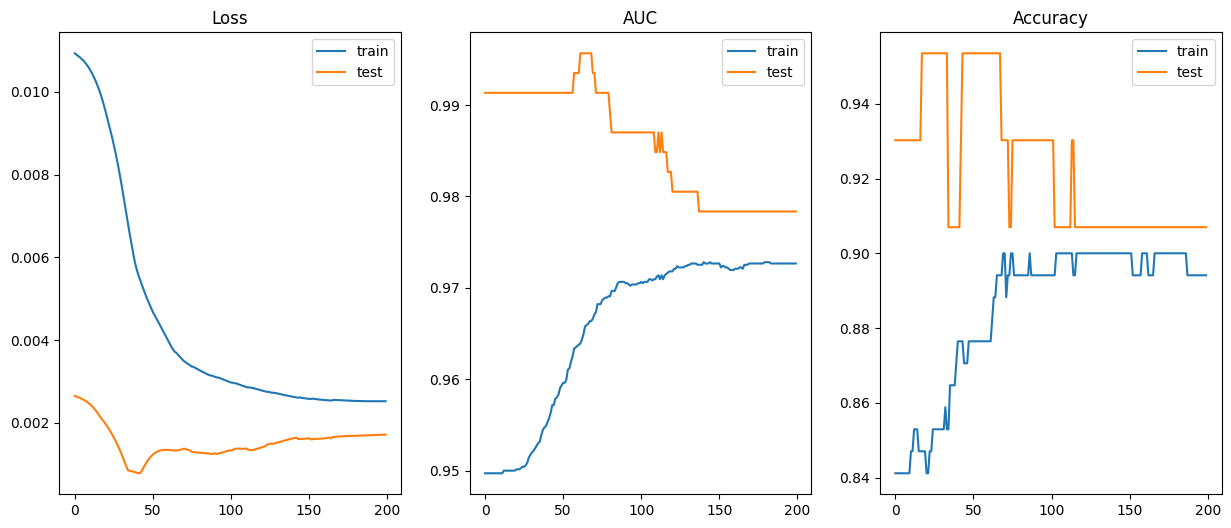

In [25]:
# Plot results
fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(131)
ax.plot(stats_train.losses,label='train')
ax.plot(stats_test.losses,label='test')
ax.set_title('Loss')
ax.legend()

ax = fig.add_subplot(1,3,2)
ax.plot(stats_train.auc_scores,label='train')
ax.plot(stats_test.auc_scores,label='test')
ax.set_title('AUC')
ax.legend()

ax = fig.add_subplot(1,3,3)
ax.plot(stats_train.acc_scores,label='train')
ax.plot(stats_test.acc_scores,label='test')
ax.set_title('Accuracy')
ax.legend()

In [26]:
# Load model from checkpoint
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint["model_state_dict"])

C:\Users\jkond\AppData\Local\Temp\ipykernel_35940\3515449824.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(PATH)


<All keys matched successfully>

In [27]:


hook = Hook(model.method_instance.monotonic_layer, append_output)
xs = []
with torch.no_grad():
    for i in range(201):
        val = i / 200.0
        x = get_simple_input(val,num_criteria)
        xs.append(val)
        model(x)

outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())
# We take every third value becouse the rest are from the normalization layer: velues for 0 and 1
outs = outs[::3] - outs[::3][0]
# Normalize the outputs to get proper weights of the criteria
outs = outs / outs[-1].sum()

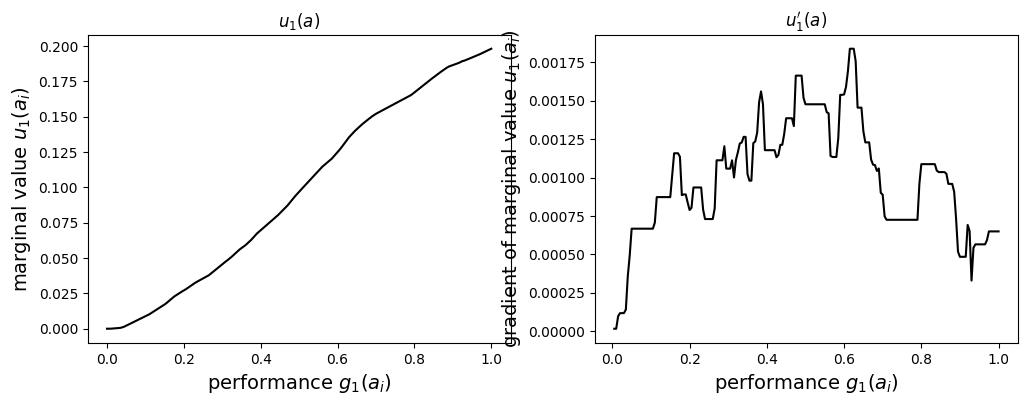

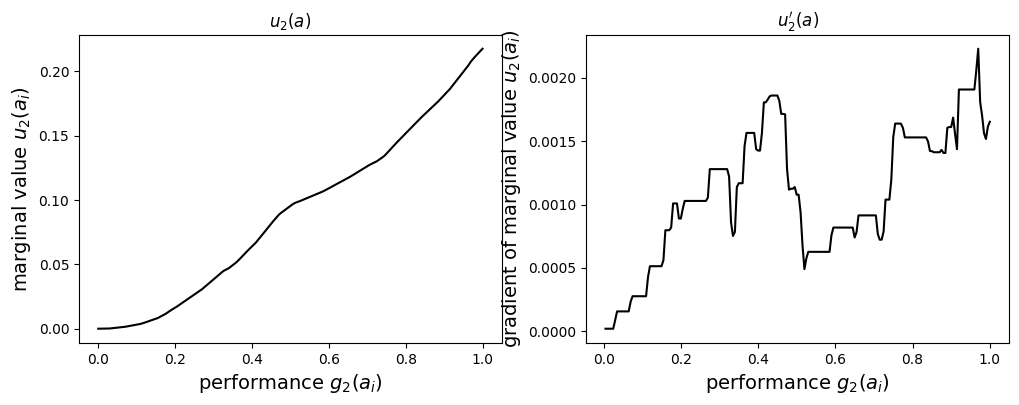

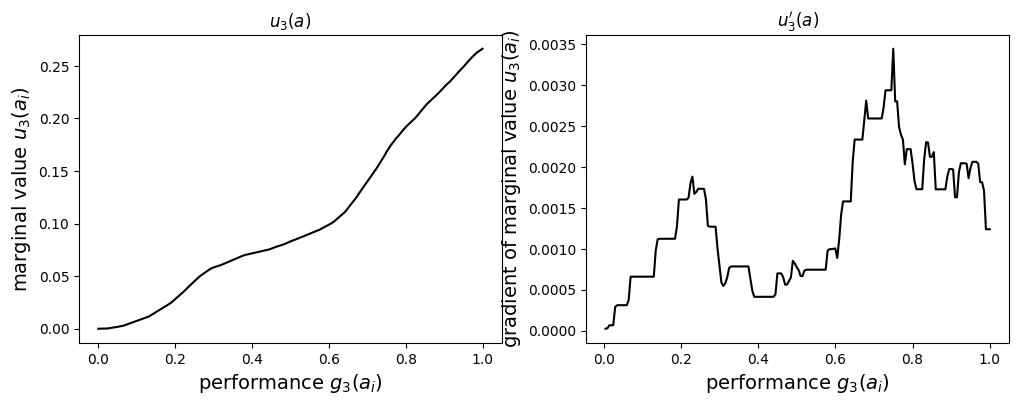

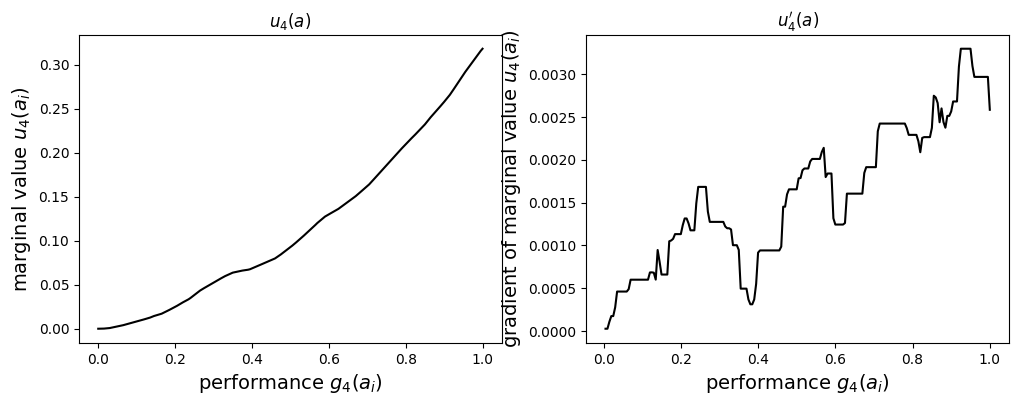

In [28]:
for i in range(num_criteria):
    criterion_number = i + 1
    fig = plt.figure(figsize=(12,4))  
    ax = fig.add_subplot(121)
    ax.set_title(f'$u_{criterion_number}(a)$')
    ax.plot(xs, outs[:, i], color="black")
    ax.set_ylabel(f"marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)

    ax = fig.add_subplot(1,2,2)
    ax.set_title(f"$u_{criterion_number}'(a)$")
    ax.plot(xs[1:], outs[1:, i]-outs[:-1, i], color="black")
    ax.set_ylabel(f"gradient of marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)
    plt.show()

In [126]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    out_train_tensor = model(X_train_t)  # wyjście modelu, np. surowa skalarna wartość
    out_test_tensor = model(X_test_t)

out_train = out_train_tensor.numpy()
out_test = out_test_tensor.numpy()

# <0 oznacza klasę 0, >0 oznacza klasę 1
y_pred_train = (out_train > 0).astype(int)
y_pred_test = (out_test > 0).astype(int)

# Metryki:
accuracy_train = accuracy_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, out_train)  # roc_auc na surowych wyjściach
f1_train = f1_score(y_train, y_pred_train)

accuracy_test = accuracy_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, out_test)
f1_test = f1_score(y_test, y_pred_test)

print(f"Accuracy train:\t{accuracy_train:.2%}")
print(f"AUC train: \t{auc_train:.2%}")
print(f"F1 train: \t{f1_train:.2%}\n")

print(f"Accuracy test:\t{accuracy_test:.2%}")
print(f"AUC test: \t{auc_test:.2%}")
print(f"F1 test: \t{f1_test:.2%}")


Accuracy train:	88.82%
AUC train: 	96.71%
F1 train: 	85.93%

Accuracy test:	93.02%
AUC test: 	99.35%
F1 test: 	92.31%


#### Wyjaśnienie decyzji

##### DALEX

In [127]:
# wrapper by było predict
class TorchModelWrapper:
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.model.eval()
        self.device = device

    def predict(self, X):
        if not isinstance(X, np.ndarray):
            X = X.values
            
        # Zamieniamy na tensor i wysyłamy na device
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(X_tensor)
        
        # Konwertujemy do numpy
        outputs_np = outputs.cpu().numpy()
        
        return outputs_np


In [128]:
from dalex import Explainer

wrapped_model = TorchModelWrapper(model=model, device='cpu')

explainer = Explainer(
    model=wrapped_model,
    data=X_train,
    y=y_train,
    model_type='classification',
    label='ANN-UTADIS'
)

Preparation of a new explainer is initiated

  -> data              : numpy.ndarray converted to pandas.DataFrame. Columns are set as string numbers.
  -> data              : 170 rows 4 cols
  -> target variable   : 170 values
  -> model_class       : __main__.TorchModelWrapper (default)
  -> label             : ANN-UTADIS
  -> predict function  : <function yhat_default at 0x0000020CD1403520> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = -0.409, mean = -0.0462, max = 0.384
  -> model type        : classification will be used
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.16, mean = 0.452, max = 1.06
  -> model_info        : package __main__

A new explainer has been created!


In [129]:
X_test_t = torch.tensor(X_test, dtype=torch.float32)

indices = [0, 3, 12] 
X_samples = X_test_t[indices]
y_samples = y_test[indices]

with torch.no_grad():
    out_test_tensor = model(X_samples)
out_test = out_test_tensor.numpy()

y_pred_test = (out_test > 0).astype(int)

In [130]:
for i, sample in enumerate(X_samples):
    print(f"Sample: {sample}, Predicted class: {y_pred_test[i]}, True class: {y_samples[i]}")
    # pred = wrapped_model.predict(X_test[indices[i]])
    # print(f"out_test: {out_test[i]}, Predicted class: {pred}") # czy to samo test - tak

Sample: tensor([1.0000, 0.6667, 0.6667, 0.6667]), Predicted class: 1, True class: 1
Sample: tensor([0.8889, 0.7778, 0.6667, 0.8333]), Predicted class: 1, True class: 1
Sample: tensor([0.5556, 0.3333, 0.0000, 0.0000]), Predicted class: 0, True class: 0


Wyjaśnienie za pomocą DALEX; podobna zasada co SHAP

In [131]:
X_samples = X_test[indices]

for idx, x in zip(indices, X_samples):
    print(f"\nWyjaśnienie decyzji dla wariantu {idx}:")

    # Reshapik
    x_reshaped = x.reshape(1, -1)

    explanation = explainer.predict_parts(x_reshaped, type='break_down')

    explanation.plot()



Wyjaśnienie decyzji dla wariantu 0:



Wyjaśnienie decyzji dla wariantu 3:



Wyjaśnienie decyzji dla wariantu 12:


##### SHAP

Using 170 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/3 [00:00<?, ?it/s]

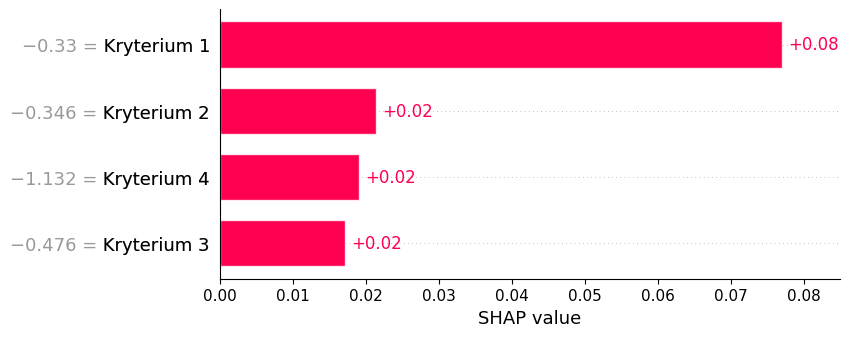

In [132]:
import shap

indices = [0, 3, 12]  # Wybrane indeksy do analizy
curr_index = 0  # Indeks aktualnie analizowanego przykładu - niestety w 1 komórce się nie wyświetla kilka razy force_plot

# Zamiana modelu na funkcję predykcji zwracającą numpy
def model_predict(X):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        out = model(X_tensor).cpu().numpy()
    return out

shap_explainer = shap.KernelExplainer(model_predict, X_train)

# Wybrane przykłady
X_samples = X_test[indices]

shap_values = shap_explainer.shap_values(X_samples)

shap.initjs()

shap.plots.bar(shap.Explanation(
    values=shap_values[0],           # wartości SHAP dla pierwszej próbki
    base_values=shap_explainer.expected_value,
    data=x_diff_scaled,              # oryginalne dane wejściowe próbki (np. X_test[indices[0]])
    feature_names=feature_names
))
shap.force_plot(shap_explainer.expected_value, shap_values[curr_index], X_samples[curr_index], feature_names=feature_names)


#### Interpretacja

##### PDP dalex

In [133]:
pdp = explainer.model_profile()
pdp.plot()


Calculating ceteris paribus: 100%|██████████| 4/4 [00:00<00:00, 118.87it/s]


Funkcje rosną monotonicznie - im większe wartości tym większa szansa na klasę 1 -  model działa poprawnie ;)

Widać też, że wartości kryteriów muszą być wysokie by mieć wpływ na przewidzenie klasy 1; losując wartości kryteriów (losowy zmyślony przykład) mamy wiekszą szansę, by model stwierdził, że jest on z klasy z klasy 0.